In [ ]:
import joblib
import json
import shap
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import japanize_matplotlib

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [15]:
from src.data import load_train, load_test, convert_category
from src.config import load_config

### exp001

In [34]:
config = load_config("../configs/baseline.yaml")
exp_name = config["experiment"]["name"]

model = joblib.load("../outputs/exp001/model.pkl")
features = joblib.load("../outputs/exp001/feature_columns.pkl")

with open("../outputs/exp001/metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

oof = pd.read_csv("../outputs/exp001/oof.csv")


train = load_train()
test = load_test()

target = config["data"]["target"]
id_col = config["data"]["id"]
drop_cols = config["feature"]["drop_columns"] + [target] + [id_col]
cat_features = config["feature"]["categorical_features"]

train, test = convert_category(train, test, cat_features)

X = train.drop(columns=drop_cols)
y = train[target]

X = X[features]

print(X.shape)
print(X.columns.equals(pd.Index(features)))

(742, 61)
True


In [22]:
lgb_model = model.models[0]

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

/opt/anaconda3/envs/StudentCup26env/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


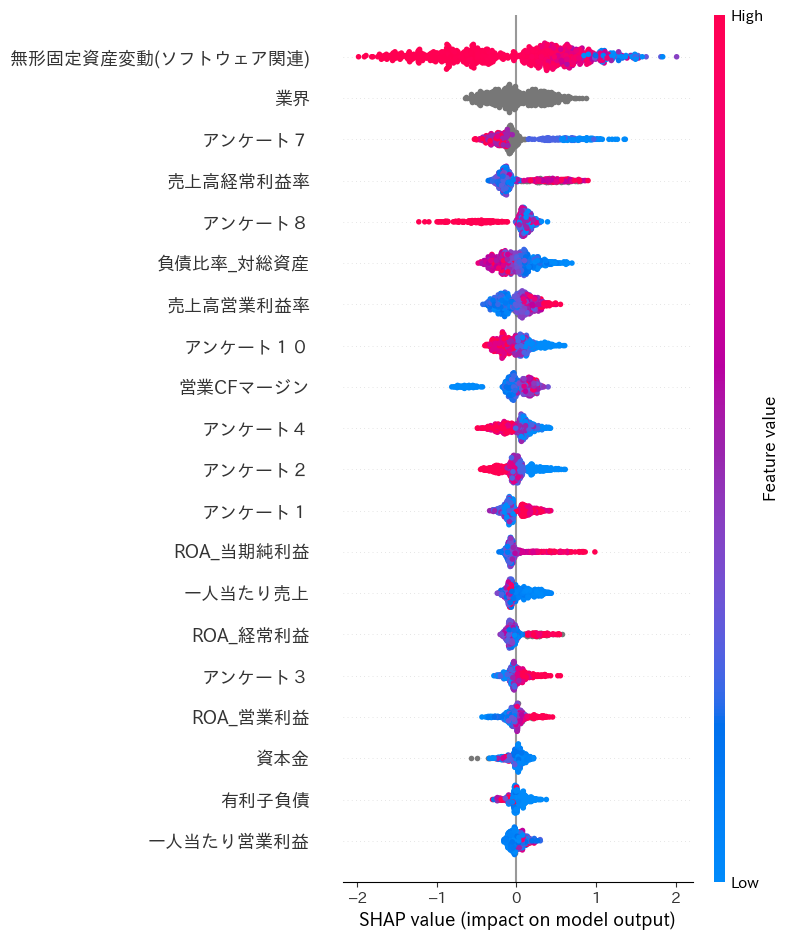

In [ ]:
shap.summary_plot(shap_values, X)
plt.savefig(f'images/{exp_name}_shap.png')

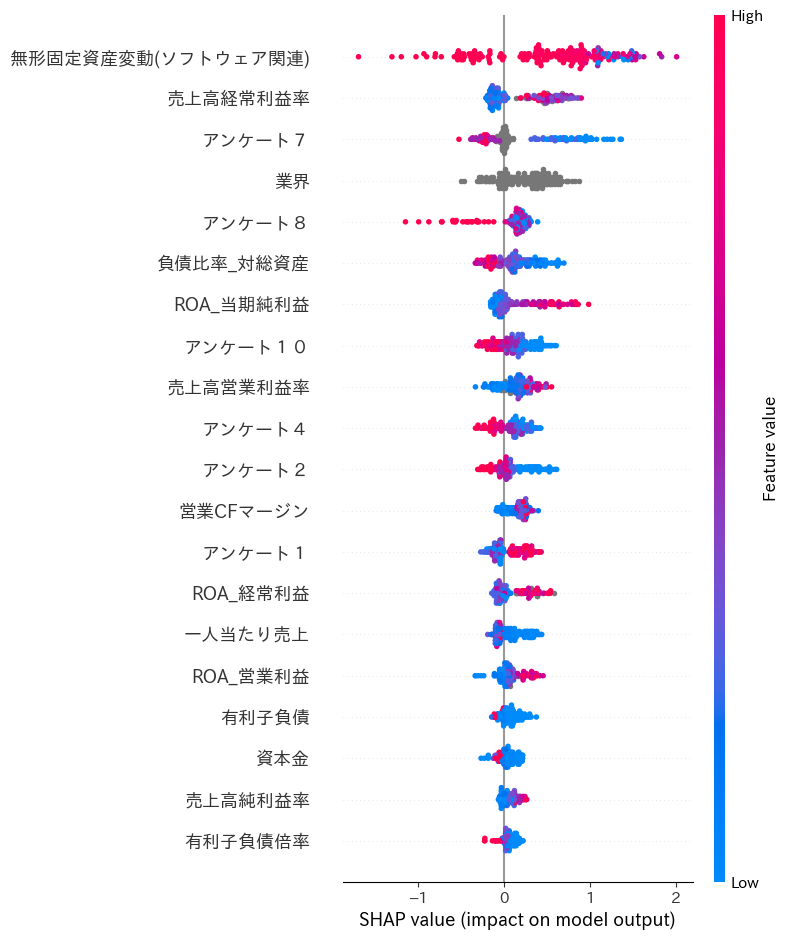

<Figure size 640x480 with 0 Axes>

In [37]:
shap.summary_plot( shap_values[y==1],X[y==1])
plt.savefig(f'images/{exp_name}_購入企業_shap.png')

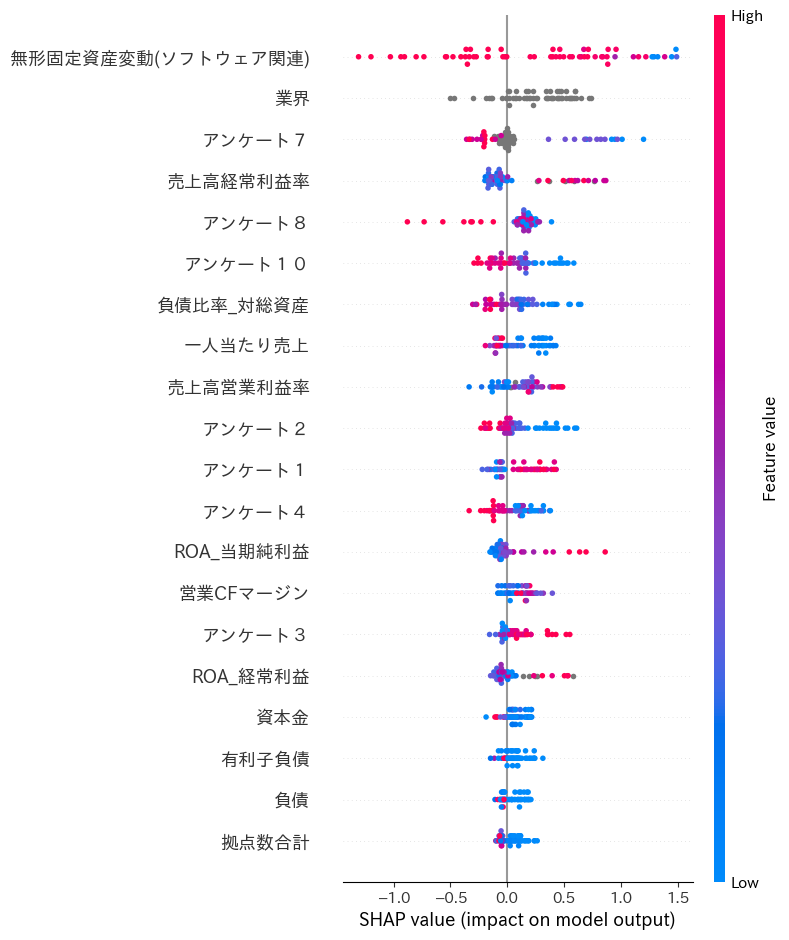

<Figure size 640x480 with 0 Axes>

In [38]:
# 見逃し （False Negative)
fn = (y==1) & (oof["prediction"] < metrics["best_threshold"])

shap.summary_plot(shap_values[fn],X[fn])
plt.savefig(f'images/{exp_name}_FN_shap.png')